In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [3]:
dataset = pd.read_csv('/content/50_Startups.csv')
print(dataset)

    R&D Spend  Administration  Marketing Spend       State     Profit
0   165349.20       136897.80        471784.10    New York  192261.83
1   162597.70       151377.59        443898.53  California  191792.06
2   153441.51       101145.55        407934.54     Florida  191050.39
3   144372.41       118671.85        383199.62    New York  182901.99
4   142107.34        91391.77        366168.42     Florida  166187.94
5   131876.90        99814.71        362861.36    New York  156991.12
6   134615.46       147198.87        127716.82  California  156122.51
7   130298.13       145530.06        323876.68     Florida  155752.60
8   120542.52       148718.95        311613.29    New York  152211.77
9   123334.88       108679.17        304981.62  California  149759.96
10  101913.08       110594.11        229160.95     Florida  146121.95
11  100671.96        91790.61        249744.55  California  144259.40
12   93863.75       127320.38        249839.44     Florida  141585.52
13   91992.39       

In [4]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   R&D Spend        50 non-null     float64
 1   Administration   50 non-null     float64
 2   Marketing Spend  50 non-null     float64
 3   State            50 non-null     object 
 4   Profit           50 non-null     float64
dtypes: float64(4), object(1)
memory usage: 2.1+ KB


In [5]:
dataset.describe(include='all')

,R&D Spend,Administration,Marketing Spend,State,Profit
count,50.000000,50.000000,50.000000,50,50.000000
unique,NaN,NaN,NaN,3,NaN
top,NaN,NaN,NaN,New York,NaN
freq,NaN,NaN,NaN,17,NaN
mean,73721.615600,121344.639600,211025.097800,NaN,112012.639200
std,45902.256482,28017.802755,122290.310726,NaN,40306.180338
min,0.000000,51283.140000,0.000000,NaN,14681.400000
25%,39936.370000,103730.875000,129300.132500,NaN,90138.902500
50%,73051.080000,122699.795000,212716.240000,NaN,107978.190000
75%,101602.800000,144842.180000,299469.085000,NaN,139765.977500


In [6]:
dataset['State'].unique()

array(['New York', 'California', 'Florida'], dtype=object)

In [7]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
ct = ColumnTransformer(transformers=[('encoder',OneHotEncoder(),['State'])],remainder='passthrough')
data_numpy = ct.fit_transform(dataset)
data_numpy

array([[0.0000000e+00, 0.0000000e+00, 1.0000000e+00, 1.6534920e+05,
        1.3689780e+05, 4.7178410e+05, 1.9226183e+05],
       [1.0000000e+00, 0.0000000e+00, 0.0000000e+00, 1.6259770e+05,
        1.5137759e+05, 4.4389853e+05, 1.9179206e+05],
       [0.0000000e+00, 1.0000000e+00, 0.0000000e+00, 1.5344151e+05,
        1.0114555e+05, 4.0793454e+05, 1.9105039e+05],
       [0.0000000e+00, 0.0000000e+00, 1.0000000e+00, 1.4437241e+05,
        1.1867185e+05, 3.8319962e+05, 1.8290199e+05],
       [0.0000000e+00, 1.0000000e+00, 0.0000000e+00, 1.4210734e+05,
        9.1391770e+04, 3.6616842e+05, 1.6618794e+05],
       [0.0000000e+00, 0.0000000e+00, 1.0000000e+00, 1.3187690e+05,
        9.9814710e+04, 3.6286136e+05, 1.5699112e+05],
       [1.0000000e+00, 0.0000000e+00, 0.0000000e+00, 1.3461546e+05,
        1.4719887e+05, 1.2771682e+05, 1.5612251e+05],
       [0.0000000e+00, 1.0000000e+00, 0.0000000e+00, 1.3029813e+05,
        1.4553006e+05, 3.2387668e+05, 1.5575260e+05],
       [0.0000000e+00, 0

In [8]:
#'New York', 'California', 'Florida'
dataset['New York'] = data_numpy[:,2]
dataset['California'] = data_numpy[:,0]
dataset['Florida'] = data_numpy[:,1]
dataset.head()

,R&D Spend,Administration,Marketing Spend,State,Profit,New York,California,Florida
0,165349.20,136897.80,471784.10,New York,192261.83,1.0,0.0,0.0
1,162597.70,151377.59,443898.53,California,191792.06,0.0,1.0,0.0
2,153441.51,101145.55,407934.54,Florida,191050.39,0.0,0.0,1.0
3,144372.41,118671.85,383199.62,New York,182901.99,1.0,0.0,0.0
4,142107.34,91391.77,366168.42,Florida,166187.94,0.0,0.0,1.0


In [9]:
#bo cot state
dataset.drop(columns='State',inplace=True)
dataset.head()

,R&D Spend,Administration,Marketing Spend,Profit,New York,California,Florida
0,165349.20,136897.80,471784.10,192261.83,1.0,0.0,0.0
1,162597.70,151377.59,443898.53,191792.06,0.0,1.0,0.0
2,153441.51,101145.55,407934.54,191050.39,0.0,0.0,1.0
3,144372.41,118671.85,383199.62,182901.99,1.0,0.0,0.0
4,142107.34,91391.77,366168.42,166187.94,0.0,0.0,1.0


In [19]:
profit_column = dataset.pop('Profit')
dataset['Profit'] = profit_column
dataset.head(5)

,R&D Spend,Administration,Marketing Spend,New York,California,Florida,Profit
0,165349.20,136897.80,471784.10,1.0,0.0,0.0,192261.83
1,162597.70,151377.59,443898.53,0.0,1.0,0.0,191792.06
2,153441.51,101145.55,407934.54,0.0,0.0,1.0,191050.39
3,144372.41,118671.85,383199.62,1.0,0.0,0.0,182901.99
4,142107.34,91391.77,366168.42,0.0,0.0,1.0,166187.94


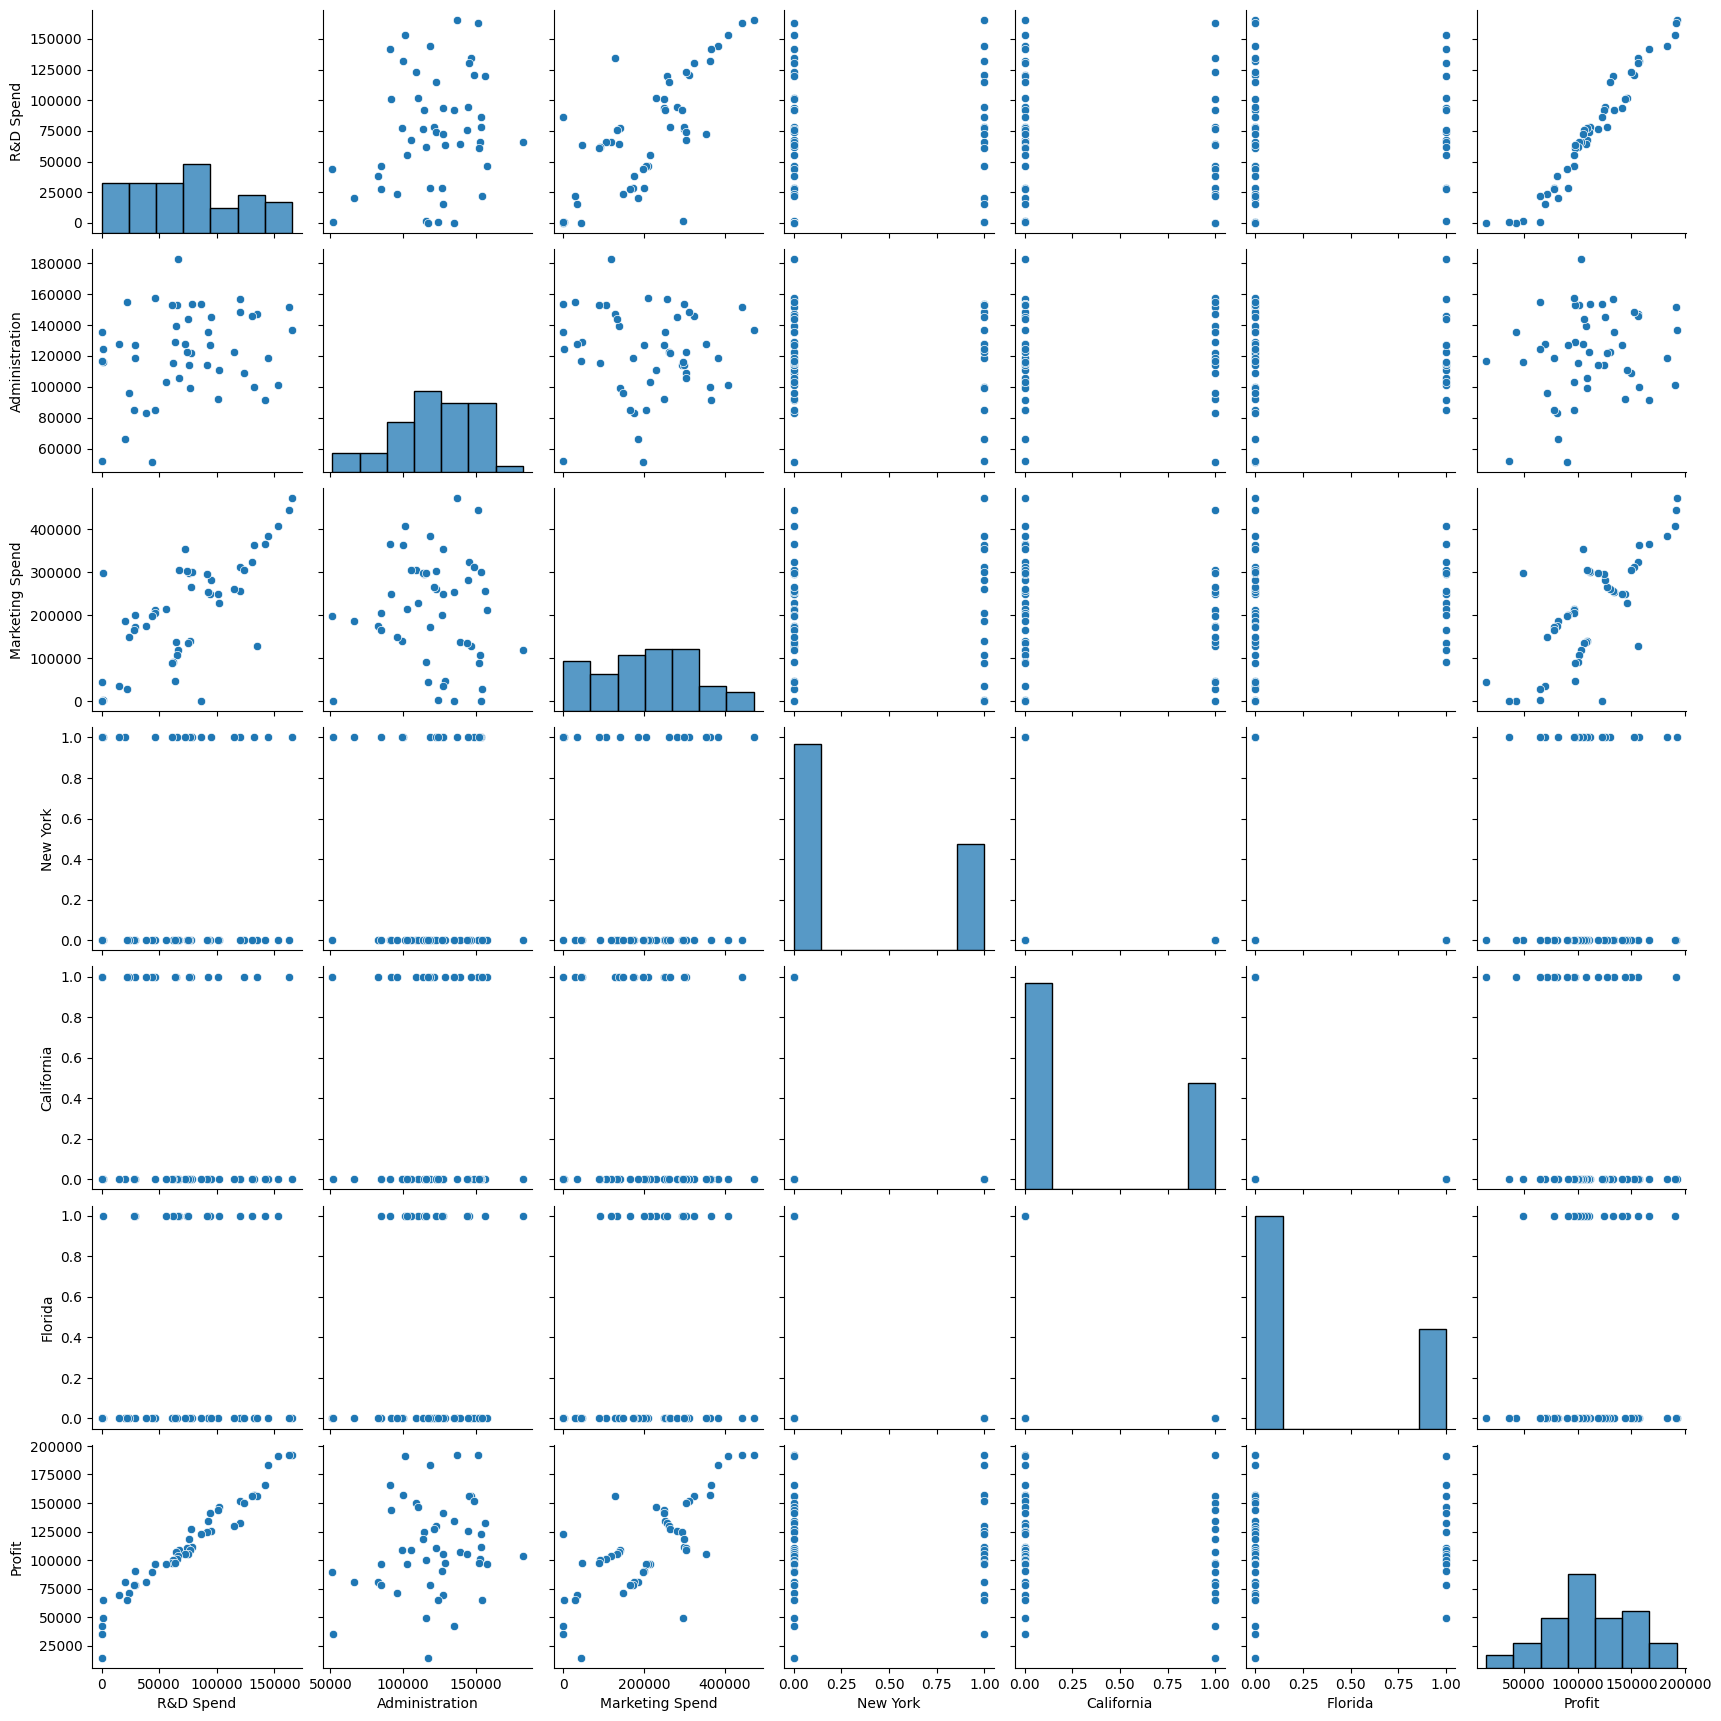

In [20]:
import seaborn as sns
sns.pairplot(dataset)

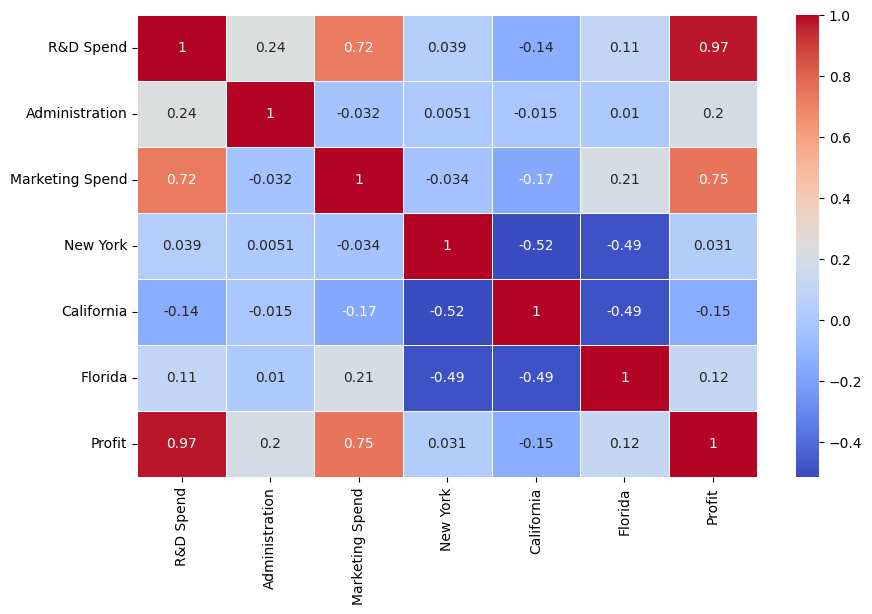

In [21]:
corr_matrix = dataset.corr()

plt.figure(figsize=(10,6))
sns.heatmap(corr_matrix,annot=True,cmap='coolwarm',linewidths=0.5)
plt.show()

In [10]:
#tach bien phu thuoc, bien doc lap
X= dataset.loc[:,['R&D Spend','Administration','Marketing Spend','New York','California','Florida']]
y= dataset.loc[:,['Profit']]
X

,R&D Spend,Administration,Marketing Spend,New York,California,Florida
0,165349.20,136897.80,471784.10,1.0,0.0,0.0
1,162597.70,151377.59,443898.53,0.0,1.0,0.0
2,153441.51,101145.55,407934.54,0.0,0.0,1.0
3,144372.41,118671.85,383199.62,1.0,0.0,0.0
4,142107.34,91391.77,366168.42,0.0,0.0,1.0
5,131876.90,99814.71,362861.36,1.0,0.0,0.0
6,134615.46,147198.87,127716.82,0.0,1.0,0.0
7,130298.13,145530.06,323876.68,0.0,0.0,1.0
8,120542.52,148718.95,311613.29,1.0,0.0,0.0
9,123334.88,108679.17,304981.62,0.0,1.0,0.0


In [11]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

In [12]:
from sklearn.linear_model import LinearRegression
regressor = LinearRegression()
regressor.fit(X_train,y_train)

LinearRegression()

In [13]:
b0 = regressor.intercept_ #diem cat truc tung
b1 = regressor.coef_      #he so goc
print(b0)
print(b1)


[42467.52924855]
[[ 7.73467193e-01  3.28845975e-02  3.66100259e-02  7.86007422e+02
   8.66383692e+01 -8.72645791e+02]]


In [14]:
y_pred = regressor.predict(X_test)
print("Giá trị dự đoán (y_pred):", y_pred[:5])
print("Giá trị thực tế (y_test):", y_test.values[:5])

Giá trị dự đoán (y_pred): [[103015.20159796]
 [132582.27760816]
 [132447.73845174]
 [ 71976.09851258]
 [178537.48221055]]
Giá trị thực tế (y_test): [[103282.38]
 [144259.4 ]
 [146121.95]
 [ 77798.83]
 [191050.39]]


# Đánh giá mô hình

In [17]:
from sklearn.metrics import mean_squared_error, r2_score,mean_absolute_error


In [18]:
print(mean_squared_error(y_test,y_pred))
print(mean_absolute_error(y_test,y_pred))
print('MRSE:',np.sqrt(mean_squared_error(y_test,y_pred)))
print('R2:',r2_score(y_test,y_pred))

83502864.03257748
7514.2936596406025
MRSE: 9137.990152794951
R2: 0.9347068473282424
